In [ ]:
# imports
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.signal import find_peaks

In [ ]:
# The notebook is in the "notebooks" folder, so we need to go up one directory
# to access the workspace root's "output" folder.
INPUT_PATH = os.path.abspath(os.path.join("..", "output", "calibration_frames"))
OUTPUT_PATH = os.path.abspath(os.path.join("..", "output", "polyfits"))

Successfully found and loaded: camera_c  apture_00000.tif


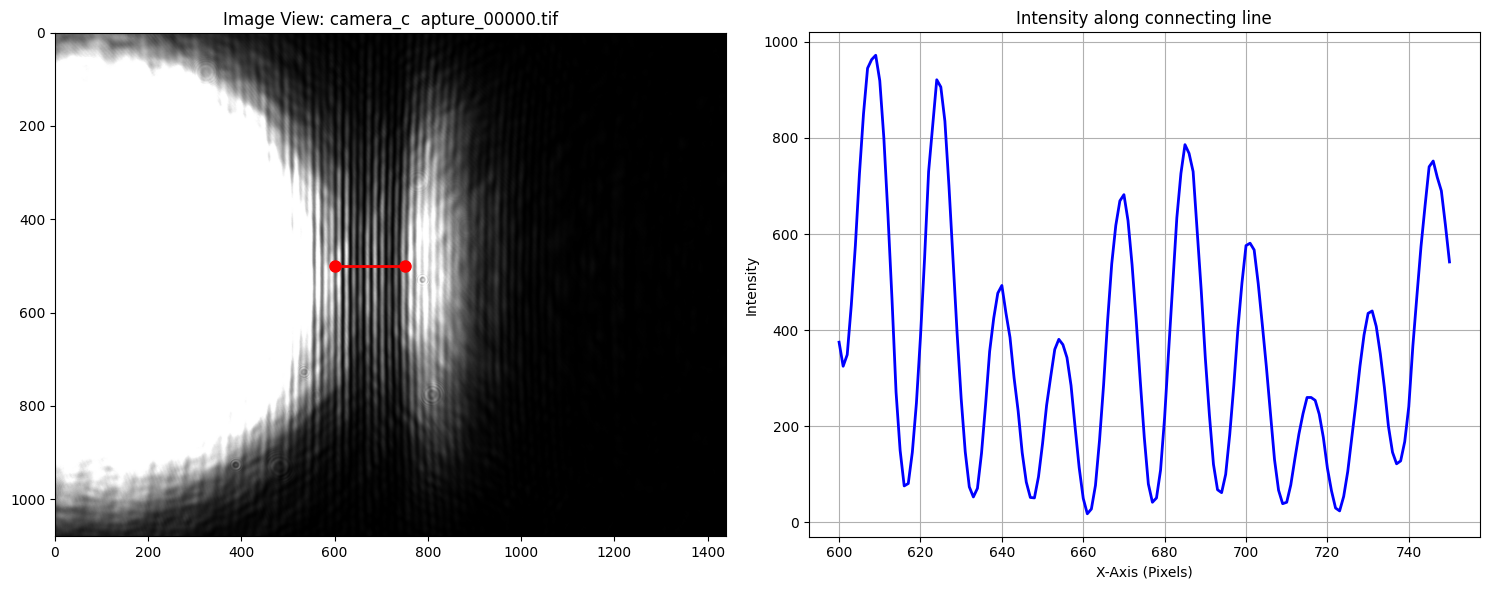

In [ ]:
# Parameters for interactive changing
frame_index = 0
x1, x2 = 600, 750
y = 500

# Try to find the file dynamically to avoid whitespace issues
search_pattern = os.path.join(INPUT_PATH, f"*{frame_index:05d}.tif")
matching_files = glob.glob(search_pattern)

if not matching_files:
    print(f"Error: Could not find any file ending with '{frame_index:05d}.tif' in {INPUT_PATH}")
    image = np.zeros((1000, 1000))
else:
    filepath = matching_files[0]
    filename = os.path.basename(filepath)
    print(f"Successfully found and loaded: {filename}")
    image = np.array(Image.open(filepath))

# Ensure x coordinates are ordered
x_start, x_end = min(x1, x2), max(x1, x2)

# Extract the intensity profile along the line
intensity_profile = image[y, x_start:x_end+1]

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Plot the image with markers and line
lo, hi = np.percentile(image, [1, 99.8])
ax1.imshow(image, cmap='gray', vmin=lo, vmax=hi)
ax1.plot([x1, x2], [y, y], color='red', linewidth=2)
ax1.plot([x1, x2], [y, y], 'ro', markersize=8)
ax1.set_title(f"Image View: {filename if matching_files else 'Fallback'}")
ax1.set_xlim(0, image.shape[1])
ax1.set_ylim(image.shape[0], 0)

# 2. Plot the intensity profile
x_pixels = np.arange(x_start, x_end+1)
ax2.plot(x_pixels, intensity_profile, color='blue', linewidth=2)
ax2.set_xlabel("X-Axis (Pixels)")
ax2.set_ylabel("Intensity")
ax2.set_title("Intensity along connecting line")
ax2.grid(True)

plt.tight_layout()
plt.show()

In [41]:
# Dictionary to map mirror_value -> intensity_profile
profiles_dict = {}

# Get all .tif files in the input directory
all_tifs = glob.glob(os.path.join(INPUT_PATH, "*.tif"))

for filepath in all_tifs:
    filename = os.path.basename(filepath)
    
    # Extract the number from strings like 'camera_c  apture_00257.tif'
    match = re.search(r'(\d+)\.tif$', filename)
    if match:
        mirror_val = int(match.group(1))
        
        # Load image and extract line intensity
        img = np.array(Image.open(filepath))
        profile_line = img[y, x_start:x_end + 1]
        
        # Add to dictionary
        profiles_dict[mirror_val] = profile_line

print(f"Processed and loaded {len(profiles_dict)} intensity profiles.")

Processed and loaded 256 intensity profiles.


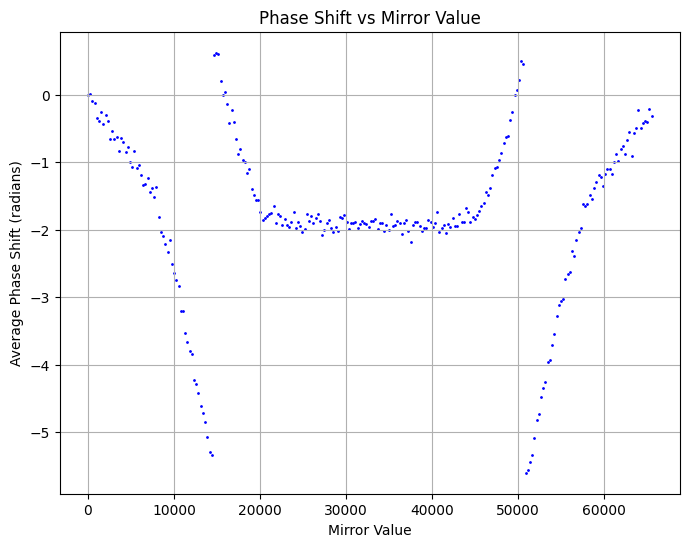

In [ ]:
def fringe_phase_fft(profile, carrier_index=None, band_width=3):
    y = profile.astype(float)

    # Remove slow background
    bg = gaussian_filter1d(y, sigma=15)
    y = y - bg

    # FFT
    F = np.fft.fft(y)

    # Use only positive frequencies
    mag = np.abs(F)
    mag[0] = 0

    if carrier_index is None:
        # find dominant positive-frequency fringe component
        half = len(y) // 2
        carrier_index = np.argmax(mag[1:half]) + 1

    # Band-pass around carrier
    F_filt = np.zeros_like(F, dtype=complex)
    k0 = carrier_index

    F_filt[k0-band_width:k0+band_width+1] = F[k0-band_width:k0+band_width+1]

    # Also keep conjugate if you want real reconstruction,
    # but for analytic phase we usually keep one side only.
    analytic = np.fft.ifft(F_filt)

    phase = np.angle(analytic)

    return phase, carrier_index


reference_phase, k0 = fringe_phase_fft(profiles_dict[00000])
phase_shifts = {}

for mirror_val, profile in profiles_dict.items():
    pahse, _ = fringe_phase_fft(profile, carrier_index=k0)
    dphi_z = np.unwrap(pahse - reference_phase)
    phase_shift = np.mean(dphi_z)
    phase_shifts[mirror_val] = phase_shift

plot_x = list(phase_shifts.keys())
plot_y = list(phase_shifts.values())

plt.figure(figsize=(8, 6))
plt.scatter(plot_x, plot_y, color='blue', s=1)
plt.xlabel("Mirror Value")
plt.ylabel("Average Phase Shift (radians)")
plt.title("Phase Shift vs Mirror Value")
plt.grid(True)

plt.show()





Saved LUT to: custom_slm_lut.lut
Measured phase stroke: 6.581 rad
Measured phase stroke: 1.047 × 2π


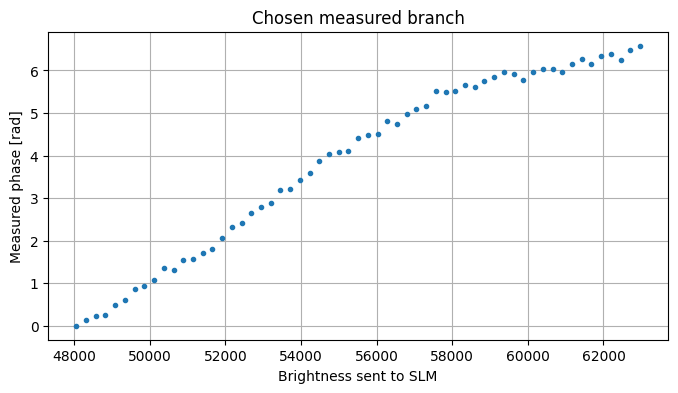

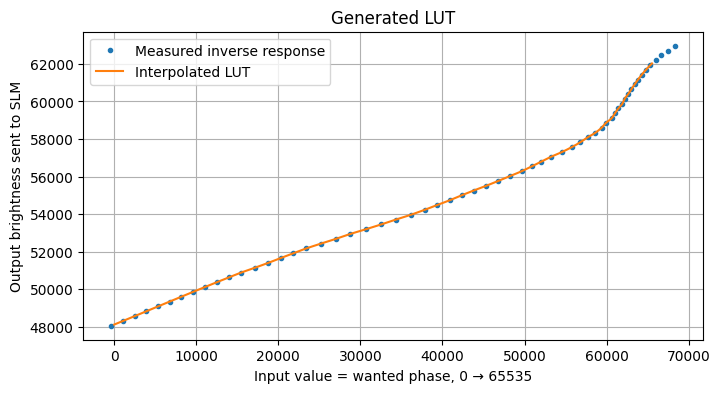

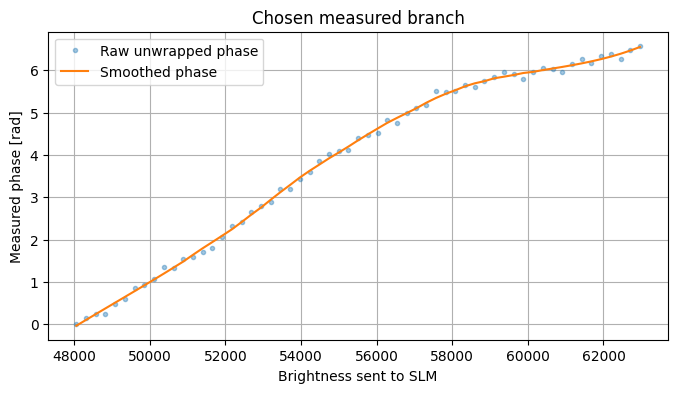

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy.signal import savgol_filter

# =========================
# INPUTS
# =========================
# brightness_values: list/array of SLM brightness values, 0–65535
# phase_values: list/array of measured phases in radians

brightness = np.array(list(phase_shifts.keys()))
phase = np.array(list(phase_shifts.values()))

# Optional: cut only high-brightness branch
BRIGHTNESS_MIN = 48000
BRIGHTNESS_MAX = 63000

mask = (brightness >= BRIGHTNESS_MIN) & (brightness <= BRIGHTNESS_MAX)

brightness = brightness[mask]
phase = phase[mask]

# Sort by brightness
order = np.argsort(brightness)
brightness = brightness[order]
phase = phase[order]

# =========================
# CLEAN + SMOOTH PHASE
# =========================

# Unwrap phase
phase = np.unwrap(phase)

# Shift chosen branch to start at zero
phase = phase - phase[0]

# Make phase increasing
if phase[-1] < phase[0]:
    phase = -phase
    phase = phase - phase[0]

# -------- smoothing --------
SMOOTH_PHASE = True

if SMOOTH_PHASE:
    # Window length must be odd and smaller than number of points
    window_length = 21
    polyorder = 3

    if window_length >= len(phase):
        window_length = len(phase) - 1

    if window_length % 2 == 0:
        window_length -= 1

    if window_length > polyorder:
        phase_smooth = savgol_filter(phase, window_length=window_length, polyorder=polyorder)
    else:
        phase_smooth = phase.copy()
else:
    phase_smooth = phase.copy()

# Enforce monotonicity by replacing tiny backwards wiggles
phase_smooth = np.maximum.accumulate(phase_smooth)

# Convert measured phase to LUT input coordinate:
# 0 phase -> input 0
# 2pi phase -> input 65535
lut_x_measured = phase_smooth / (2 * np.pi) * 65535
lut_y_measured = brightness

# =========================
# BUILD FULL LUT
# =========================
interp = PchipInterpolator(lut_x_measured, lut_y_measured, extrapolate=False)

lut_input = np.arange(65536)
lut_output = interp(lut_input)

# Fill values outside measured range by saturation
lut_output = np.where(
    np.isnan(lut_output),
    np.where(lut_input < lut_x_measured[0], lut_y_measured[0], lut_y_measured[-1]),
    lut_output
)

lut_output = np.clip(np.round(lut_output), 0, 65535).astype(np.uint16)

# =========================
# SAVE LUT
# =========================
out_path = "custom_slm_lut.lut"

with open(out_path, "w") as f:
    for inp, out in zip(lut_input, lut_output):
        f.write(f"{inp} {int(out)}\n")

print(f"Saved LUT to: {out_path}")
print(f"Measured phase stroke: {phase.max() - phase.min():.3f} rad")
print(f"Measured phase stroke: {(phase.max() - phase.min()) / (2*np.pi):.3f} × 2π")

# =========================
# PLOTS
# =========================
plt.figure(figsize=(8, 4))
plt.plot(brightness, phase, ".")
plt.xlabel("Brightness sent to SLM")
plt.ylabel("Measured phase [rad]")
plt.title("Chosen measured branch")
plt.grid()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(lut_x_measured, lut_y_measured, ".", label="Measured inverse response")
plt.plot(lut_input, lut_output, "-", label="Interpolated LUT")
plt.xlabel("Input value = wanted phase, 0 → 65535")
plt.ylabel("Output brightness sent to SLM")
plt.title("Generated LUT")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(brightness, phase, ".", alpha=0.4, label="Raw unwrapped phase")
plt.plot(brightness, phase_smooth, "-", label="Smoothed phase")
plt.xlabel("Brightness sent to SLM")
plt.ylabel("Measured phase [rad]")
plt.title("Chosen measured branch")
plt.legend()
plt.grid()
plt.show()


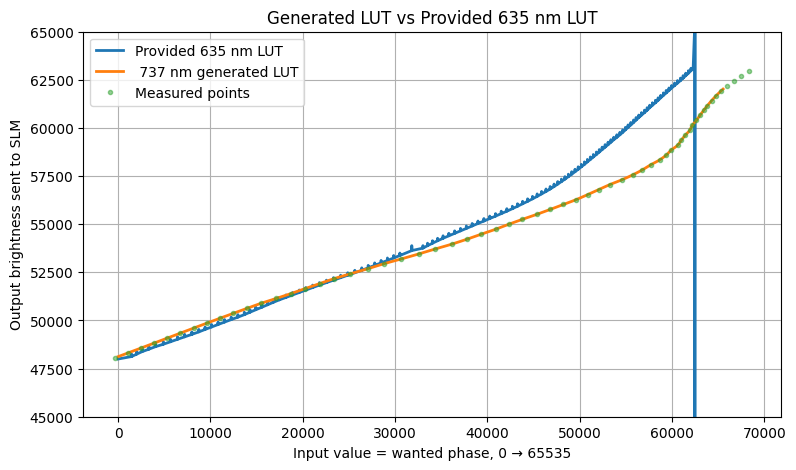

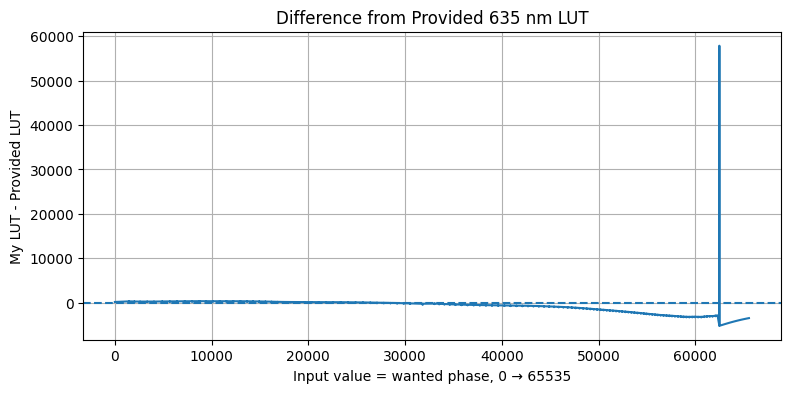

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# LOAD PROVIDED LUT
# =========================
provided_lut_path = "slm3324_at635_DVI.lut"  # change if needed

provided_lut = np.loadtxt(provided_lut_path)

provided_input = provided_lut[:, 0]
provided_output = provided_lut[:, 1]

# =========================
# PLOT COMPARISON
# =========================
plt.figure(figsize=(9, 5))

plt.plot(
    provided_input,
    provided_output,
    label="Provided 635 nm LUT",
    linewidth=2,
)

plt.plot(
    lut_input,
    lut_output,
    label=" 737 nm generated LUT",
    linewidth=2,
)

plt.plot(
    lut_x_measured,
    lut_y_measured,
    ".",
    alpha=0.5,
    label="Measured points",
)

plt.xlabel("Input value = wanted phase, 0 → 65535")
plt.ylabel("Output brightness sent to SLM")
plt.title("Generated LUT vs Provided 635 nm LUT")
plt.grid()
plt.legend()
plt.ylim(45000, 65000)

plt.show()

# =========================
# OPTIONAL: DIFFERENCE PLOT
# =========================
provided_interp = np.interp(lut_input, provided_input, provided_output)

diff = lut_output.astype(float) - provided_interp

plt.figure(figsize=(9, 4))
plt.plot(lut_input, diff)
plt.axhline(0, linestyle="--")

plt.xlabel("Input value = wanted phase, 0 → 65535")
plt.ylabel("My LUT - Provided LUT")
plt.title("Difference from Provided 635 nm LUT")
plt.grid()
plt.show()

In [52]:
peaks_dict = {}

for mirror_val, profile in profiles_dict.items():
    # Find peaks (added basic distance and prominence to filter out noise)
    # Adjust prominence if needed based on intensity range
    peaks, _ = find_peaks(profile, distance=10, prominence=max(profile) * 0.1)
    peaks_dict[mirror_val] = peaks

print(f"Found peaks for {len(peaks_dict)} profiles.")

Found peaks for 256 profiles.


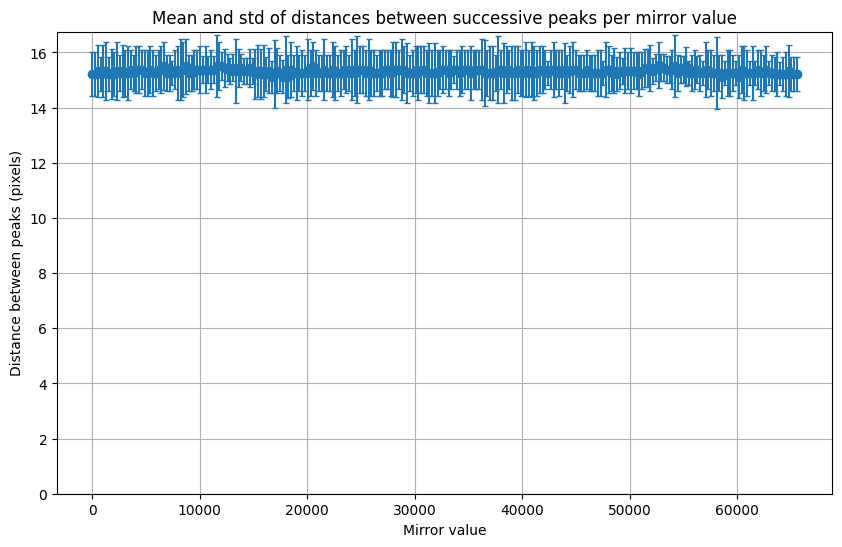

In [ ]:
import numpy as np

# compute mean and std of distances between successive peaks for each profile

mirror_vals = sorted(profiles_dict.keys())
mean_dists = []
std_dists = []
valid_mirrors = []

for mv in mirror_vals:
    peaks = peaks_dict.get(mv)
    if peaks is None or len(peaks) < 2:
        # skip entries without at least two peaks
        continue
    d = np.diff(peaks)  # distance in pixels between successive peaks
    mean_dists.append(d.mean())
    std_dists.append(d.std())
    valid_mirrors.append(mv)

mean_dists = np.array(mean_dists)
std_dists = np.array(std_dists)
valid_mirrors = np.array(valid_mirrors)

# plot mean with std as error bars
plt.figure(figsize=(10, 6))
plt.errorbar(valid_mirrors, mean_dists, yerr=std_dists, fmt='o-', capsize=2)
plt.xlabel("Mirror value")
plt.ylabel("Distance between peaks (pixels)")
plt.title("Mean and std of distances between successive peaks per mirror value")
plt.ylim(0, None)  # set y-axis to start at 0
plt.grid(True)
plt.show()

In [ ]:
# Ensure output directory exists before saving
os.makedirs(OUTPUT_PATH, exist_ok=True)

# We use the same x_pixels range as before
x_pixels = np.arange(x_start, x_end + 1)
saved_count = 0

for mirror_val, profile in profiles_dict.items():
    plt.figure(figsize=(10, 5))
    plt.plot(x_pixels, profile, color='blue', linewidth=2, label="Intensity Profile")
    
    # Check if we have peaks for this mirror_val and plot them
    if mirror_val in peaks_dict:
        peaks = peaks_dict[mirror_val]
        # 'peaks' contains the indices relative to the sliced 'profile' array.
        # x_pixels[peaks] grabs the true absolute x-coordinates values based off x_start!
        plt.plot(x_pixels[peaks], profile[peaks], "x", color='red', markersize=10, label="Peaks")
        
    plt.xlabel("X-Axis (Pixels)")
    plt.ylabel("Intensity")
    plt.title(f"Intensity Profile - Mirror: {mirror_val}")
    plt.grid(True)
    plt.legend()
    
    # Save the figure
    save_filename = f"intensity_profile_{mirror_val:05d}.png"
    save_filepath = os.path.join(OUTPUT_PATH, save_filename)
    plt.savefig(save_filepath)
    plt.close() # Close figure to free memory
    saved_count += 1

print(f"Successfully saved {saved_count} plots with marked peaks to '{OUTPUT_PATH}'")

Successfully saved 256 plots with marked peaks to 'c:\Users\Eitan\Documents\SLM\output\polyfits'
